In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import sqlite3

repos_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/gitskills_data/data/repos/*.parquet'
artifacts_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/gitskills_data/data/artifacts/*.parquet'
artifact_siblings_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/gitskills_data/data/artifact_siblings/*.parquet'
mining_runs_path = '/Users/home/workspace/School/Advanced_Software_Engineering/Project/work/SWE-Group-Project--Project-3/src/data/gitskills_data/data/mining_runs/*.parquet'

con = duckdb.connect(database=':memory:')

## Exploratory Data Analysis (EDA)

#### Integrity checks
The dedup flag must mark exactly 1 representation per file hash.

In [7]:
representatives = con.execute(f"""
    SELECT COUNT(*)                  AS rows_total,
       SUM(dedup_primary)        AS representatives,
       COUNT(DISTINCT file_sha)  AS distinct_hashes,
       (SELECT COUNT(*) FROM (SELECT file_sha FROM read_parquet('{artifacts_path}') GROUP BY file_sha
                              HAVING SUM(dedup_primary) <> 1)) AS bad_groups,
       SUM(dedup_primary = 1 AND (content IS NULL OR content = '')) AS reps_without_text,
       SUM(dedup_primary = 0 AND content IS NOT NULL AND content <> '') AS copies_with_text
FROM read_parquet('{artifacts_path}')
""").df()
representatives.T.rename(columns={0: "value"}).astype(int)

,value
rows_total,3797117
representatives,1877981
distinct_hashes,1877981
bad_groups,0
reps_without_text,0
copies_with_text,2348


Total number of artifacts: 3797117. \
Total number of unique file hashes: 1877981

Content should be empty when dedup_primary is 0, and non-empty when dedup_primary is 1. This is by design to save space.
There are some records which are not empty though they are marked as duplicates. This number is harmless. It will not affect our analysis in any way.


#### Copies per content

In [12]:
copy_content_frequency = con.execute(f"""
    SELECT cp as number_of_copies, COUNT(*) as number_of_skills
    FROM (SELECT COUNT(*) AS cp
      FROM read_parquet('{artifacts_path}')
      GROUP BY file_sha)
    GROUP BY cp
    ORDER BY cp
""").df()
copy_content_frequency

,number_of_copies,number_of_skills
0,1,1489480
1,2,179980
2,3,74431
3,4,38678
4,5,22763
...,...,...
333,1074,1
334,1176,1
335,1245,1
336,1252,1


This means that there are 1,489,480 skills that have only 1 copy. There are 179,980 skills that have exactly 2 copies, and so on. The maximum number of copies for a single skill is 1,409.

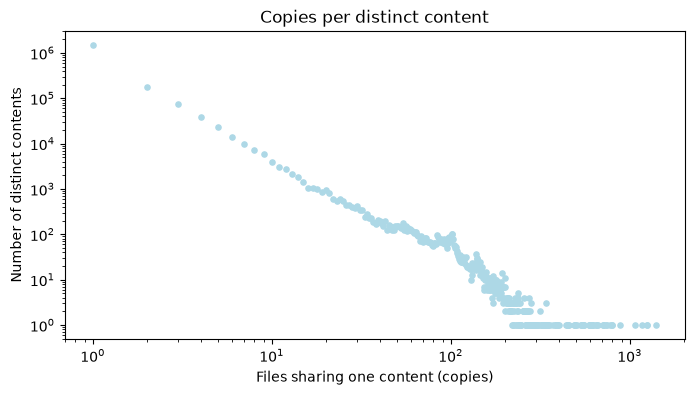

In [25]:
dist = copy_content_frequency
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(dist.number_of_copies, dist.number_of_skills, s=14, c="lightblue")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Files sharing one content (copies)"); ax.set_ylabel("Number of distinct contents")
ax.set_title("Copies per distinct content")
plt.show()
# dist.head(10).to_frame("contents")

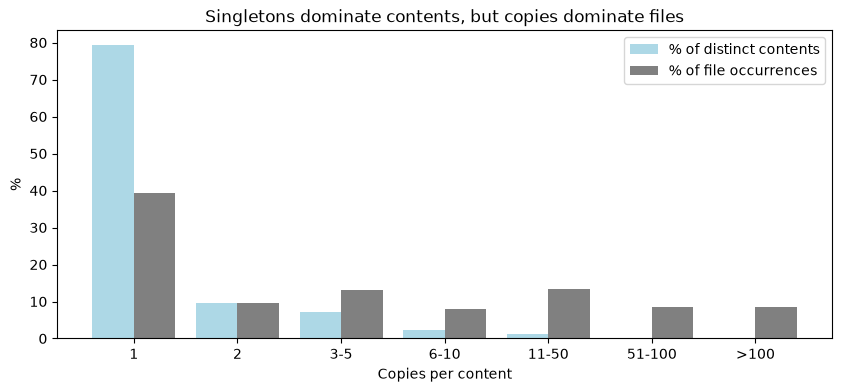

,distinct_skills,total_files,% distinct_skills,% total_files
copy_bucket,,,,
1,1489480,1489480,79.3,39.2
2,179980,359960,9.6,9.5
3-5,135872,491820,7.2,13.0
6-10,40914,303615,2.2,8.0
11-50,25140,510266,1.3,13.4
51-100,4492,322613,0.2,8.5
>100,2103,319363,0.1,8.4


In [37]:
file_frequency = con.execute(f"""
    select
        a.file_sha,
        count(*) as files
    FROM read_parquet('{artifacts_path}') a
    LEFT JOIN read_parquet('{repos_path}') r ON r.full_name = a.repo_full_name
    GROUP BY a.file_sha
""").df()

bins   = [0, 1, 2, 5, 10, 50, 100, np.inf]
labels = ["1", "2", "3-5", "6-10", "11-50", "51-100", ">100"]
file_frequency["copy_bucket"] = pd.cut(file_frequency.files, bins=bins, labels=labels)
bk = file_frequency.groupby("copy_bucket", observed=False).agg(distinct_skills=("file_sha", "size"), total_files=("files", "sum"))
bk["% distinct_skills"] = (100 * bk.distinct_skills / bk.distinct_skills.sum()).round(1)
bk["% total_files"]    = (100 * bk.total_files / bk.total_files.sum()).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(bk)); w = .4
ax.bar(x - w/2, bk["% distinct_skills"], w, label="% of distinct contents", color="lightblue")
ax.bar(x + w/2, bk["% total_files"],    w, label="% of file occurrences", color="gray")
ax.set_xticks(x, bk.index); ax.set_xlabel("Copies per content"); ax.set_ylabel("%")
ax.set_title("Singletons dominate contents, but copies dominate files"); ax.legend()
plt.show()
bk

**Findings (full dataset, 1,877,981 distinct skills / 3,797,117 files)**
- Most skills are unique: 79.3% of distinct skills exist as a single file.
- Most files are shared: 60.8% of files belong to a skill with two or more
  copies; 50.5% of all files are redundant copies (matching the dataset paper).
- Duplication is concentrated: 31,735 skills with more than 10 copies
  (1.6% of distinct skills) account for 30.3% of all files; the 2,103 skills
  with more than 100 copies alone account for 8.4%.
- The sample overstates duplication (74.0% singletons vs 79.3% here) because
  it includes every copy of each selected skill; cite full-dataset figures.

In [40]:
file_frequency = con.execute(f"""
    SELECT MAX(a.name) AS name,
       COUNT(DISTINCT a.repo_full_name) AS repos,
       COUNT(DISTINCT r.owner)          AS owners,
       COUNT(*)                         AS files_per_skill
    FROM read_parquet('{artifacts_path}') a JOIN read_parquet('{repos_path}') r ON r.full_name = a.repo_full_name
    GROUP BY a.file_sha
    ORDER BY owners DESC
""").df()
file_frequency

,name,repos,owners,files_per_skill
0,frontend-design,951,897,1245
1,verification-before-completion,914,866,1252
2,webapp-testing,781,741,1176
3,systematic-debugging,656,629,885
4,pdf,661,612,1409
...,...,...,...,...
1877976,cis-apache-12.3,1,1,1
1877977,antigravity-workflows,1,1,1
1877978,sch-submit,1,1,1
1877979,kubeblocks,1,1,1


## Most-adopted skills: files per skill, repos and owners

**Findings (full dataset)**
- The most-adopted skills come from a few curated sources: 9 of the top 10 by
  distinct owners match Anthropic's official skills (`frontend-design`, `pdf`,
  `pptx`, `webapp-testing`, `canvas-design`) or the Superpowers collection
  (`verification-before-completion`, `systematic-debugging`,
  `test-driven-development`, `receiving-code-review`).
- `frontend-design` leads with 897 owners across 951 repos (1,245 files).
- Files overstate adoption unevenly: `pdf` has 2.3 files per owner, while
  `fastapi` has 1.1.
- Repos and owners nearly coincide for top skills (owners are 94–97% of repos),
  so in-repo mirroring, not multi-repo copying, drives the file inflation.
- Each row counts one exact text; versions of the same skill split across
  `file_sha` groups, so these figures are a lower bound on adoption.

In [44]:
file_frequency = con.execute(f"""
    SELECT COUNT(*) AS SHARED_NAMES,  SUM(n) AS SKILLS_INVOLVED
    FROM (SELECT lower(name) AS nm, COUNT(*) AS n
      FROM read_parquet('{artifacts_path}')
      WHERE dedup_primary = 1 AND name <> ''
      GROUP BY nm
      HAVING n > 1)
""").df().astype(int)
file_frequency

,SHARED_NAMES,SKILLS_INVOLVED
0,162855,950937


## Names are not identity

**Question:** Can a skill's front-matter `name` identify the same skill across
repositories?

**Method:** Among distinct skills (`dedup_primary = 1`, so every row is a
different text), group by lowercase `name` and count how many different texts
share each name.

**Findings (full dataset)**
- 162,855 names are each used by two or more different skills.
- Together they cover 950,937 distinct skills, about half (50.6%) of all
  1,877,981 distinct skills.
- On average, a shared name is attached to about 5.8 different texts.
- The most shared names are generic verbs and tasks (in the sample: `code-review`
  with 37 different texts, `commit`, `plan`, `review`, `debug`), alongside
  names of widely copied skills such as `skill-creator`, whose many variants
  are likely edited versions of one source.

**Why it happens**
- *Name collisions:* unrelated skills independently pick the same generic name.
- *Edited copies:* one skill is copied and modified, so the text (and hash)
  changes but the name stays.
- The reverse also occurs: template families produce near-identical skills with
  different names (see the near-duplicate section).

**Implication:** A shared name is not evidence of shared content, and a
different name is not evidence of different content. We identify exact copies
by `file_sha` and related versions by text similarity; `name` is used only as a
label.

**Caveats**
- Names are compared after lowercasing only; `code_review` and `code-review`
  count as different names, so collisions are, if anything, understated.
- Skills with empty names are excluded.

In [46]:
skill_names_reused = con.execute(f"""
    SELECT lower(name) AS nm, COUNT(*) AS n
      FROM read_parquet('{artifacts_path}')
      WHERE dedup_primary = 1 AND name <> ''
      GROUP BY nm
      ORDER BY n DESC;
""").df()
skill_names_reused

,nm,n
0,code-review,3690
1,skill-creator,2765
2,commit,2461
3,review,2208
4,frontend-design,2161
...,...,...
845416,run-spacesim,1
845417,graphixengine,1
845418,migrate-repo,1
845419,version-bump-tag,1


## Most reused skill names

**Question:** Which front-matter names are used by the most *different* skills?

**Method:** Among distinct skills (`dedup_primary = 1`, one row per unique
text), group by lowercase `name` and count the distinct texts per name.

**Findings (full dataset)**

| Name | Distinct skills using it |
|---|---|
| code-review | 3,690 |
| skill-creator | 2,765 |
| commit | 2,461 |
| review | 2,208 |
| frontend-design | 2,161 |
| release | 1,959 |
| brainstorming | 1,423 |
| plan | 1,315 |
| systematic-debugging | 1,307 |
| tdd | 1,270 |

The top names fall into two groups that reflect different mechanisms:

- **Generic task names** (`code-review`, `commit`, `review`, `release`, `plan`,
  `tdd`). These describe common development tasks, so unrelated authors
  likely arrive at the same name independently: *name collisions*.
- **Names of well-known published skills** (`skill-creator`, `frontend-design`,
  `brainstorming`, `systematic-debugging`). These come from widely promoted
  sources (Anthropic's official skills and the Superpowers collection), so their
  many texts are likely *edited versions of one original*.

The second group connects to adoption: the single most-adopted
`frontend-design` text appears in 897 owners' repositories, yet 2,161 different
texts carry that name. Counting one exact text understates how far a popular
skill has spread.

**Implication:** For generic names, a shared name says little about shared
content. For names of published skills, it often marks a family of edited
versions, which text similarity (not hashing) is needed to group.

**Caveats**
- Collision vs edited-version is inferred from the name type, not measured;
  the near-duplicate analysis tests it directly.
- Names are compared after lowercasing only, so variants such as `code_review`
  or `code-reviewer` are counted separately.